In [ ]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys

import random
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [28]:
REGION = 'ExtNord'
YEAR = 2015

In [29]:
grouped_file = pd.read_csv(f'../../data/ExtNord/CM_{REGION}_Timeline_{YEAR}_grouped.csv', encoding=enc)
grouped_file_previous = pd.read_csv(f'../../data/ExtNord/CM_{REGION}_Timeline_{YEAR-1}_grouped.csv', encoding=enc)

In [30]:
grouped_file.head()

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.193720,-0.107755,-0.368326,0.107755,0.194397,-0.106597,-0.366073,0.106597,0.012763,0.014083,0.014467,0.014083,25.68,34.58,16.78,12.80,43.00,0.0,0.0,0.0,30.54,26.08,66.88,282.41,51.0,12.0,39.0,30.33,30.33,33.5,27.83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.168083,-0.119696,-0.352593,0.119696,0.169689,-0.117560,-0.351610,0.117560,0.010680,0.011892,0.011157,0.011892,26.24,35.49,16.99,12.72,43.99,0.0,0.0,0.0,30.67,24.33,59.35,410.84,53.0,12.0,41.0,30.67,30.67,35.5,27.17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.186568,-0.100576,-0.358255,0.100576,0.189237,-0.099525,-0.362545,0.099525,0.010527,0.008578,0.009904,0.008578,25.53,34.59,16.48,12.36,42.44,0.0,0.0,0.0,29.46,23.75,59.38,383.44,52.0,12.0,40.0,30.00,30.00,34.5,25.83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.192535,-0.110211,-0.365544,0.110211,0.191105,-0.111085,-0.367493,0.111085,0.008786,0.009590,0.011213,0.009590,25.28,33.81,16.75,12.28,41.80,0.0,0.0,0.0,29.42,23.17,60.96,381.88,50.0,12.0,38.0,30.00,30.00,34.0,26.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.184092,-0.100503,-0.358690,0.100503,0.181272,-0.101963,-0.357540,0.101963,0.012842,0.013507,0.011516,0.013507,25.77,35.01,16.52,13.03,43.30,0.0,0.0,0.0,30.04,24.42,61.04,409.24,53.0,13.0,40.0,31.00,31.00,35.5,26.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
grouped_file.shape

(3804, 50)

In [32]:
grouped_file_previous.head()

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2014-01,2014,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.229944,-0.106548,-0.406425,0.106548,0.235708,-0.099787,-0.399243,0.099787,0.016117,0.016614,0.012368,0.016614,26.66,36.36,16.79,15.29,41.26,0.0000,0.0000,0.0000,30.67,24.83,63.68,276.61,53.0,14.0,39.0,29.17,29.33,34.33,28.83,1345.0,483.0,0.0,143.14,1072.0,0.0,85.0,911.0
1,2014-01,2014,1,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.233327,-0.120509,-0.403203,0.120509,0.237530,-0.110815,-0.396799,0.110815,0.015537,0.013778,0.008671,0.013778,27.25,38.35,16.02,13.94,42.84,0.0000,0.0000,0.0000,31.54,26.42,64.43,304.11,54.0,13.0,41.0,29.67,29.83,35.00,29.33,1228.0,422.0,0.0,140.46,982.0,0.0,91.0,784.0
2,2014-01,2014,1,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.216790,-0.091465,-0.385743,0.091465,0.225764,-0.079123,-0.382786,0.079123,0.010775,0.008443,0.008236,0.008443,27.04,37.23,16.92,15.70,41.54,0.0001,0.0025,0.0025,30.08,24.83,63.68,292.20,52.0,13.0,39.0,27.83,29.17,34.17,27.33,1324.0,475.0,0.0,144.61,1070.0,0.0,74.0,701.0
3,2014-01,2014,1,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.244099,-0.098628,-0.399229,0.098628,0.239033,-0.091542,-0.394136,0.091542,0.011823,0.010843,0.011842,0.010843,26.08,34.95,17.07,15.13,40.66,0.0001,0.0017,0.0017,29.92,24.33,60.83,282.71,52.0,12.0,40.0,27.83,28.83,33.83,27.00,1301.0,476.0,0.0,144.58,1048.0,0.0,63.0,693.0
4,2014-01,2014,1,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.238072,-0.091182,-0.404626,0.091182,0.238932,-0.088755,-0.400715,0.088755,0.022838,0.020541,0.012782,0.020541,27.04,37.18,16.80,14.97,41.79,0.0002,0.0062,0.0062,30.71,25.08,64.32,279.17,53.0,14.0,39.0,28.17,29.50,34.17,28.17,1268.0,440.0,0.0,142.37,1023.0,0.0,180.0,1023.0


In [33]:
grouped_file_previous.shape

(3804, 50)

In [34]:
grouped_file['dt_placement'] = pd.to_datetime(grouped_file['dt_placement'], errors='coerce').dt.to_period('M')
grouped_file_previous['dt_placement'] = pd.to_datetime(grouped_file_previous['dt_placement'], errors='coerce').dt.to_period('M')

In [35]:
grouped_file

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.193720,-0.107755,-0.368326,0.107755,0.194397,-0.106597,-0.366073,0.106597,0.012763,0.014083,0.014467,0.014083,25.68,34.58,16.78,12.80,43.00,0.0000,0.0000,0.0000,30.54,26.08,66.88,282.41,51.0,12.0,39.0,30.33,30.33,33.50,27.83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.168083,-0.119696,-0.352593,0.119696,0.169689,-0.117560,-0.351610,0.117560,0.010680,0.011892,0.011157,0.011892,26.24,35.49,16.99,12.72,43.99,0.0000,0.0000,0.0000,30.67,24.33,59.35,410.84,53.0,12.0,41.0,30.67,30.67,35.50,27.17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.186568,-0.100576,-0.358255,0.100576,0.189237,-0.099525,-0.362545,0.099525,0.010527,0.008578,0.009904,0.008578,25.53,34.59,16.48,12.36,42.44,0.0000,0.0000,0.0000,29.46,23.75,59.38,383.44,52.0,12.0,40.0,30.00,30.00,34.50,25.83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.192535,-0.110211,-0.365544,0.110211,0.191105,-0.111085,-0.367493,0.111085,0.008786,0.009590,0.011213,0.009590,25.28,33.81,16.75,12.28,41.80,0.0000,0.0000,0.0000,29.42,23.17,60.96,381.88,50.0,12.0,38.0,30.00,30.00,34.00,26.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.184092,-0.100503,-0.358690,0.100503,0.181272,-0.101963,-0.357540,0.101963,0.012842,0.013507,0.011516,0.013507,25.77,35.01,16.52,13.03,43.30,0.0000,0.0000,0.0000,30.04,24.42,61.04,409.24,53.0,13.0,40.0,31.00,31.00,35.50,26.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3799,2015-12,2015,12,0.0,1.000,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,0.203088,-0.137169,-0.351249,0.137169,0.207896,-0.132811,-0.351074,0.132811,0.007534,0.009796,0.007947,0.009796,23.24,31.04,15.43,13.32,35.07,0.0086,0.2667,0.2667,27.83,25.00,62.50,309.20,49.0,9.0,40.0,28.33,28.33,31.83,25.17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3800,2015-12,2015,12,0.0,1.000,extreme nord,mayo-tsanaga,roua,ndimche,13.968570,10.827287,0.225139,-0.106725,-0.344386,0.106725,0.234570,-0.100006,-0.346271,0.100006,0.017684,0.020319,0.013223,0.020319,22.98,30.09,15.86,13.23,34.27,0.0201,0.6233,0.6233,28.08,23.33,59.83,313.94,48.0,9.0,39.0,28.83,28.83,32.00,25.67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3801,2015-12,2015,12,0.0,1.000,extreme nord,mayo-tsanaga,roua,roua,13.968570,10.779370,0.238564,-0.097891,-0.356575,0.097891,0.236759,-0.099079,-0.352076,0.099079,0.021547,0.028422,0.014361,0.028422,22.84,29.47,16.22,13.51,33.09,0.0100,0.3100,0.3100,28.12,22.75,58.33,337.18,48.0,9.0,39.0,28.83,28.83,32.50,25.17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3802,2015-12,2015,12,0.0,1.000,extreme nord,mayo-tsanaga,roua,soulede,13.917498,10.736254,0.232344,-0.121116,-0.366003,0.121116,0.234013,-0.120951,-0.366089,0.120951,0.012583,0.012218,0.009853,0.012218,23.50,31.61,15.38,12.93,36.11,0.0097,0.3020,0.3020,28.42,25.00,62.50,349.57,50.0,10.0,40.0,29.67,29.67,33.17,25.17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
biovars_df = grouped_file_previous[['year', 'GID0', 'GID1', 'GID2', 'GID3'] + [col for col in grouped_file_previous.columns if 'bio' in col] ].copy()
biovars_df.rename(columns={'year': 'year_biovars'}, inplace=True)

In [37]:
biovars_df.head()

,year_biovars,GID0,GID1,GID2,GID3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2014,extreme nord,diamare,bogo,balaza,30.67,24.83,63.68,276.61,53.0,14.0,39.0,29.17,29.33,34.33,28.83,1345.0,483.0,0.0,143.14,1072.0,0.0,85.0,911.0
1,2014,extreme nord,diamare,bogo,balda,31.54,26.42,64.43,304.11,54.0,13.0,41.0,29.67,29.83,35.00,29.33,1228.0,422.0,0.0,140.46,982.0,0.0,91.0,784.0
2,2014,extreme nord,diamare,bogo,bogo,30.08,24.83,63.68,292.20,52.0,13.0,39.0,27.83,29.17,34.17,27.33,1324.0,475.0,0.0,144.61,1070.0,0.0,74.0,701.0
3,2014,extreme nord,diamare,bogo,borai,29.92,24.33,60.83,282.71,52.0,12.0,40.0,27.83,28.83,33.83,27.00,1301.0,476.0,0.0,144.58,1048.0,0.0,63.0,693.0
4,2014,extreme nord,diamare,bogo,guinggley,30.71,25.08,64.32,279.17,53.0,14.0,39.0,28.17,29.50,34.17,28.17,1268.0,440.0,0.0,142.37,1023.0,0.0,180.0,1023.0


In [38]:
biovars_df.shape

(3804, 24)

In [39]:
dataset = grouped_file.drop(columns=[col for col in grouped_file.columns if 'bio' in col]).copy()

In [40]:
dataset.shape

(3804, 31)

In [41]:
dataset.rename(columns={'dt_placement': 'dt_placement_original'}, inplace=True)
dataset['year_biovars'] = dataset['year']-1
dataset['dt_prediction'] = dataset['dt_placement_original'] + 3

In [42]:
dataset.head()

,dt_placement_original,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,year_biovars,dt_prediction
0,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.193720,-0.107755,-0.368326,0.107755,0.194397,-0.106597,-0.366073,0.106597,0.012763,0.014083,0.014467,0.014083,25.68,34.58,16.78,12.80,43.00,0.0,0.0,0.0,2014,2015-04
1,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.168083,-0.119696,-0.352593,0.119696,0.169689,-0.117560,-0.351610,0.117560,0.010680,0.011892,0.011157,0.011892,26.24,35.49,16.99,12.72,43.99,0.0,0.0,0.0,2014,2015-04
2,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.186568,-0.100576,-0.358255,0.100576,0.189237,-0.099525,-0.362545,0.099525,0.010527,0.008578,0.009904,0.008578,25.53,34.59,16.48,12.36,42.44,0.0,0.0,0.0,2014,2015-04
3,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.192535,-0.110211,-0.365544,0.110211,0.191105,-0.111085,-0.367493,0.111085,0.008786,0.009590,0.011213,0.009590,25.28,33.81,16.75,12.28,41.80,0.0,0.0,0.0,2014,2015-04
4,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.184092,-0.100503,-0.358690,0.100503,0.181272,-0.101963,-0.357540,0.101963,0.012842,0.013507,0.011516,0.013507,25.77,35.01,16.52,13.03,43.30,0.0,0.0,0.0,2014,2015-04


In [43]:
dataset.shape

(3804, 33)

In [49]:
dataset = pd.merge(dataset, biovars_df, on=['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

<Axes: >

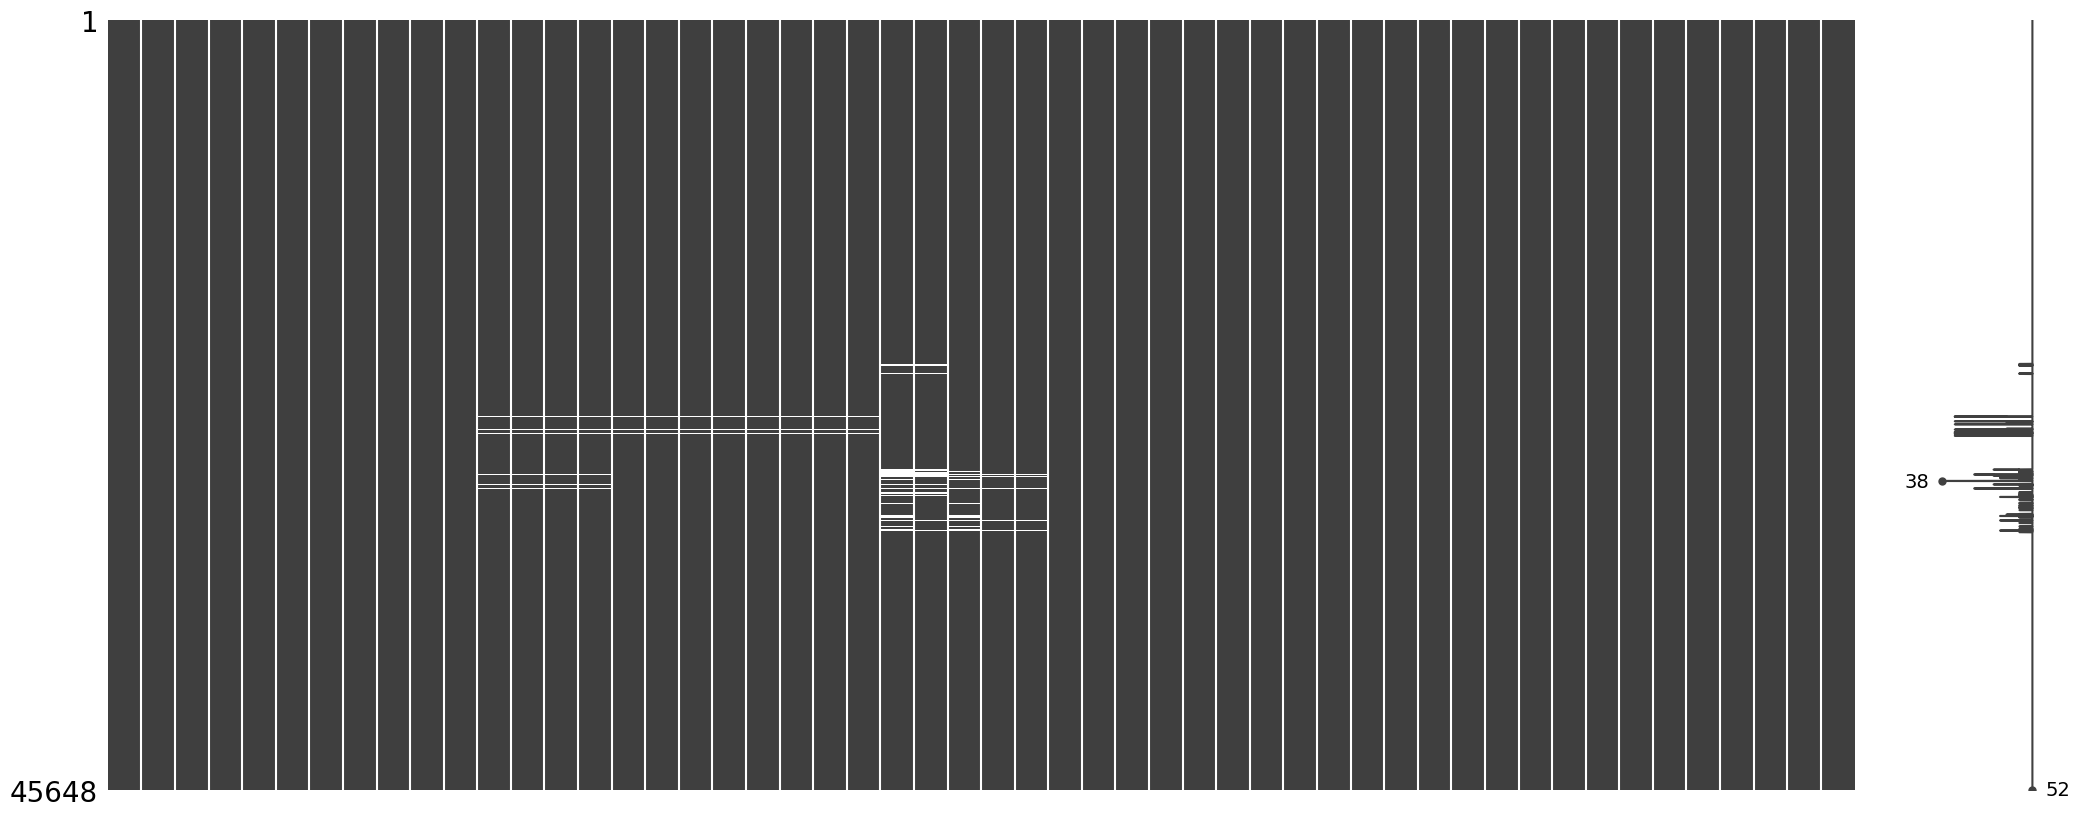

In [50]:
msno.matrix(dataset)

In [51]:
dataset

,dt_placement_original,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,year_biovars,dt_prediction,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.78656,0.193720,-0.107755,-0.368326,0.107755,0.194397,-0.106597,-0.366073,0.106597,0.012763,0.014083,0.014467,0.014083,25.68,34.58,16.78,12.80,43.00,0.0000,0.00,0.00,2014,2015-04,30.67,24.83,63.68,276.61,53.0,14.0,39.0,29.17,29.33,34.33,28.83,1345.0,483.0,0.0,143.14,1072.0,0.0,85.0,911.0
1,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.78656,0.193720,-0.107755,-0.368326,0.107755,0.194397,-0.106597,-0.366073,0.106597,0.012763,0.014083,0.014467,0.014083,25.68,34.58,16.78,12.80,43.00,0.0000,0.00,0.00,2014,2015-04,30.67,24.83,63.68,276.61,53.0,14.0,39.0,29.17,29.33,34.33,28.83,1345.0,483.0,0.0,143.14,1072.0,0.0,85.0,911.0
2,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.78656,0.193720,-0.107755,-0.368326,0.107755,0.194397,-0.106597,-0.366073,0.106597,0.012763,0.014083,0.014467,0.014083,25.68,34.58,16.78,12.80,43.00,0.0000,0.00,0.00,2014,2015-04,30.67,24.83,63.68,276.61,53.0,14.0,39.0,29.17,29.33,34.33,28.83,1345.0,483.0,0.0,143.14,1072.0,0.0,85.0,911.0
3,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.78656,0.193720,-0.107755,-0.368326,0.107755,0.194397,-0.106597,-0.366073,0.106597,0.012763,0.014083,0.014467,0.014083,25.68,34.58,16.78,12.80,43.00,0.0000,0.00,0.00,2014,2015-04,30.67,24.83,63.68,276.61,53.0,14.0,39.0,29.17,29.33,34.33,28.83,1345.0,483.0,0.0,143.14,1072.0,0.0,85.0,911.0
4,2015-01,2015,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.78656,0.193720,-0.107755,-0.368326,0.107755,0.194397,-0.106597,-0.366073,0.106597,0.012763,0.014083,0.014467,0.014083,25.68,34.58,16.78,12.80,43.00,0.0000,0.00,0.00,2014,2015-04,30.67,24.83,63.68,276.61,53.0,14.0,39.0,29.17,29.33,34.33,28.83,1345.0,483.0,0.0,143.14,1072.0,0.0,85.0,911.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45643,2015-12,2015,12,0.0,1.000,extreme nord,mayo-tsanaga,roua,zogom,14.005050,10.74344,0.229814,-0.122233,-0.349424,0.122233,0.236194,-0.112987,-0.348697,0.112987,0.018427,0.019469,0.013557,0.019469,24.68,32.51,16.84,14.73,37.05,0.0074,0.23,0.23,2014,2016-03,29.83,22.17,69.27,239.63,48.0,16.0,32.0,26.83,29.50,32.67,26.83,1564.0,534.0,0.0,134.57,1175.0,0.0,153.0,1175.0
45644,2015-12,2015,12,0.0,1.000,extreme nord,mayo-tsanaga,roua,zogom,14.005050,10.74344,0.229814,-0.122233,-0.349424,0.122233,0.236194,-0.112987,-0.348697,0.112987,0.018427,0.019469,0.013557,0.019469,24.68,32.51,16.84,14.73,37.05,0.0074,0.23,0.23,2014,2016-03,29.83,22.17,69.27,239.63,48.0,16.0,32.0,26.83,29.50,32.67,26.83,1564.0,534.0,0.0,134.57,1175.0,0.0,153.0,1175.0
45645,2015-12,2015,12,0.0,1.000,extreme nord,mayo-tsanaga,roua,zogom,14.005050,10.74344,0.229814,-0.122233,-0.349424,0.122233,0.236194,-0.112987,-0.348697,0.112987,0.018427,0.019469,0.013557,0.019469,24.68,32.51,16.84,14.73,37.05,0.0074,0.23,0.23,2014,2016-03,29.83,22.17,69.27,239.63,48.0,16.0,32.0,26.83,29.50,32.67,26.83,1564.0,534.0,0.0,134.57,1175.0,0.0,153.0,1175.0
45646,2015-12,2015,12,0.0,1.000,extreme nord,mayo-tsanaga,roua,zogom,14.005050,10.74344,0.229814,-0.122233,-0.349424,0.122233,0.236194,-0.112987,-0.348697,0.112987,0.018427,0.019469,0.013557,0.019469,24.68,32.51,16.84,14.73,37.05,0.0074,0.23,0.23,2014,2016-03,29.83,22.17,69.27,239.63,48.0,16.0,32.0,26.83,29.50,32.67,26.83,1564.0,534.0,0.0,134.57,1175.0,0.0,153.0,1175.0
